<img src="logo.png" width="200" height="60" align="left"/>  </div> <div style="text-align: right"> <div style="font-size: 20px;"> Máster Universitario en Visión Artificial</span></div></div>

# <div style="text-align: center"> <div style="font-size: 32px;"> <span style="color:#365275"> <strong>Práctica Imagen Médica: Mediapipe Hands</span> </div>


<div style="text-align: justify;">

Como hemos visto en clase en el ámbito clínico la escala MDS-UPDRS es ampliamente utilizada para la evaluación de la enfermedad de Parkinson. Entre las pruebas incluidas en esta escala para la valoración de la bradicinesia en miembros superiores se encuentra el <strong>Finger Tapping Test</strong>. Como puede observarse en este **[vídeo](https://www.youtube.com/shorts/rTOcc4R7yb4)**,  esta prueba consiste en llevar a cabo el golpeteo del dedo índice con el pulgar durante al menos 10 veces tan rápida y ampliamente como sea posible.  Por medio de esta prueba, los neurólogos pretenden evaluar aspectos como la amplitud, velocidad, titubeos, interrupciones y disminución de la amplitud del movimiento, explorando cada mano por separado.

El objetivo de esta práctica es realizar una simulación de esta prueba por medio de la adquisición de vídeos de corta duración que posteriormente serán procesados, empleando una de las herramientas de detección de keypoints vistas en clase, **Mediapipe Hands**, a partir de la cual será posible automatizar la estimación de los parámetros previamente enumerados.
Para la consecución de la práctica propuesta se plantean las siguientes tareas:
</div>

   1. <div style="text-align: justify;"> Adquisición de vídeos cortos realizando Finger Tapping Test. Inicialmente se adquirirá un vídeo realizando el movimiento lo más amplio y rápido posible. Posteriormente, se deberá grabar otro vídeo en en el que se simule un escenario de bradicinesia típico que puede observarse como consecuencia de la presencia de la enfermedad de Pakinson. Para ello se deberán introducir durante la ejecución de la prueba interrupciones en el movimiento, titubeos, así como disminución de la velocidad y amplitud del movimiento. </div>
      
<div style="text-align: justify; border-left: 10px solid #FFA500; padding: 10px; background-color: #FFF3CD; width: 100%; font-size: 16px;"> <strong>Nota:</strong> se recomienda que el dispositivo utilizado para adquirir los vídeos, ya sea una cámara o móvil permanezca estático durante la grabación, con el objetivo de poder caracterizar adecuadamente el movimiento. Por otro lado, se recomienda que la persona se encuentre próxima a la cámara con el objetivo de facilitar la detección de los keypoints de interés. Finalmente, sólo debe observarse una mano en escena, pues está en esta prueba se valoran las manos por separado. </div>

2. <div style="text-align: justify;"> Detección de keypoints de la mano empleando la herramienta <strong>Mediapipe Hands</strong>. Una vez se hayan identificado los diferentes landmarks asociados a la mano en cada frame, el alumno deberá seleccionar los keypoints que considere oportunos para la caracterización del movimiento en esta prueba. </div>
4.	<div style="text-align: justify;"> Representar gráficamente la posición o distancias de los keypoints de interés en cada frame del vídeo. </div>
5.	<div style="text-align: justify;"> Identificación de los golpeteos (taps) realizados durante la prueba en la gráfica generada. </div>
<div style="text-align: justify; border-left: 10px solid #FFA500; padding: 10px; background-color: #FFF3CD; width: 100%; font-size: 16px;"> <strong> Nota:</strong> para la identificación de los taps se recomienda detectar los picos y valles (máximos y mínimos locales) de la gráfica generada empleando la herramienta del paquete Scipy: <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html" target="_blank" style="color: #007BFF; font-weight: bold; text-decoration: none;">
        find_peaks
    </a>. </div>


6.	<div style="text-align: justify;"> Cuantificación de al menos 2 features de interés que permitan valorar la realización de la prueba (velocidad, amplitud, titubeos, interrupciones y disminución de la amplitud). </div>


<div style="text-align: justify;">

# <div style="text-align: left"> <div style="font-size: 30px;"> <span style="color:#365275"> <strong>Mediapipe Hands</strong></span> </div>

<div style="text-align: justify;">

MediaPipe Hands es una solución de seguimiento de manos y dedos de alta precisión desarrollado por Google. Utiliza aprendizaje automático (ML) para inferir 21 puntos de referencia 3D de una mano a partir de una sola imagen.


</div>

## <span style="background-color:  #c4fbff">Modelos </span>


#### - **Modelo de Detección de Palmas**  

Para detectar la ubicación inicial de las manos, diseñaron un modelo de detector de una sola toma (*single-shot detector*) optimizado para su uso en tiempo real en dispositivos móviles, de manera similar al modelo de detección facial en <strong>MediaPipe Face Mesh</strong>. Detectar manos es una tarea decididamente compleja: tanto el modelo liviano como el modelo completo deben funcionar en una amplia variedad de tamaños de manos con una gran variabilidad de escala (~20x) en relación con el marco de la imagen, además de poder detectar manos ocluidas y autoocluídas. Mientras que los rostros presentan patrones de alto contraste, por ejemplo, en las regiones de los ojos y la boca, la falta de tales características en las manos hace que su detección confiable sea más difícil únicamente a partir de sus características visuales. En su lugar, proporcionar contexto adicional, como el brazo, el cuerpo o las características de la persona, ayuda a una localización precisa de la mano.

Este método aborda estos desafíos utilizando diferentes estrategias. Primero, entrenaron un detector de <strong>palmas</strong> en lugar de un detector de manos, ya que estimar los cuadros delimitadores de objetos rígidos como las palmas y los puños es significativamente más simple que detectar manos con dedos articulados. Además, dado que las palmas son objetos más pequeños, el algoritmo de <strong>supresión de no máximos (NMS)</strong> funciona bien incluso en casos de autooclusión de dos manos, como los apretones de manos. Asimismo, las palmas pueden modelarse utilizando <strong>cajas delimitadoras cuadradas</strong> (*anchors* en terminología de aprendizaje automático), ignorando otras relaciones de aspecto y reduciendo así el número de *anchors* en un factor de 3 a 5. En segundo lugar, se emplea un <strong>extractor de características tipo encoder-decoder</strong> para proporcionar una mejor conciencia del contexto de la escena, incluso para objetos pequeños (similar al enfoque <strong>RetinaNet</strong>). Por último, minimizaron la <strong>pérdida focal (focal loss)</strong> durante el entrenamiento para gestionar la gran cantidad de *anchors* resultantes de la alta variabilidad en la escala.

Con estas técnicas, logran una <strong>precisión promedio del 95.7%</strong> en la detección de palmas. Usando una pérdida de entropía cruzada estándar y sin *decoder*, la precisión base sería de solo <strong>86.22%</strong>.



#### - **Modelo de Puntos de Referencia de la Mano**  
Después de la detección de la palma en toda la imagen, el modelo de puntos de referencia de la mano realiza una <strong>localización precisa de los 21 puntos clave (véase la imagen) 3D de los nudillos de la mano</strong> dentro de las regiones detectadas, a través de una regresión, es decir, predicción directa de coordenadas. El modelo aprende una representación interna coherente de la postura de la mano y es robusto incluso ante manos parcialmente visibles y autooclusiones.

Para obtener datos de referencia (*ground truth*), <strong>anotaron manualmente ~30,000 imágenes del mundo real</strong> con 21 coordenadas 3D, como se muestra a continuación (tomaron el valor <strong>Z</strong> del mapa de profundidad de la imagen, si existe para la coordenada correspondiente). Para cubrir mejor las posibles posturas de la mano y proporcionar una supervisión adicional sobre la naturaleza de la geometría de la mano, también renderizaron un modelo sintético de mano de alta calidad sobre diversos fondos y lo mapearon a sus respectivas coordenadas 3D.

</div>
<img src="hand_landmarks_mediapipe.png" width="800" height="300" align="center"/>




## <span style="background-color:  #c4fbff">Instalación de dependencias </span>

In [2]:
!pip install mediapipe==0.10.33 opencv-python matplotlib scipy numpy

<div style="text-align: justify;">
<strong> HandLandmarker</strong> de MediaPipe requiere un archivo de modelo preentrenado (.task)
para realizar la detección de manos y la estimación de sus puntos clave (landmarks).
Este modelo no se incluye automáticamente en el paquete de Python, por lo que debe
descargarse por separado.


El siguiente snippet de código descarga el archivo de modelo necesario desde el almacenamiento oficial
de MediaPipe y lo guarda localmente, de modo que pueda ser cargado posteriormente
por HandLandmarker. </div>

In [4]:
import urllib.request

# URL of the remote file to download (MediaPipe hand landmark model)
url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

# Local file name (or path) where the downloaded file will be saved
output_path = "./hand_landmarker.task"

# Download the file from the URL and save it to the specified local path
urllib.request.urlretrieve(url, output_path)

print("Downloaded to:", output_path)

Downloaded to: ./hand_landmarker.task


<div style="text-align: justify;">

## <span style="background-color:  #c4fbff">Configuración</span>

El detector de manos **Hand Landmarker** de MediaPipe permite ajustar varios parámetros de configuración:

**- running_mode:** Define el modo de ejecución de la tarea. Puede tomar los valores **IMAGE**, **VIDEO** o **LIVE_STREAM**.
**IMAGE** se utiliza para imágenes individuales, **VIDEO** para fotogramas decodificados de un vídeo y **LIVE_STREAM** para una secuencia en tiempo real, como una cámara.

**- num_hands:** Especifica el número máximo de manos que se intentarán detectar. El valor predeterminado es **1**.

**- min_hand_detection_confidence:** Valor mínimo de confianza para considerar válida la detección de la palma de la mano. El valor predeterminado es **0.5**.

**- min_hand_presence_confidence:** Valor mínimo de confianza de presencia de mano en el modelo de landmarks. En los modos **VIDEO** y **LIVE_STREAM**, si este valor cae por debajo del umbral, se vuelve a ejecutar la detección de palma. El valor predeterminado es **0.5**.

**- min_tracking_confidence:** Valor mínimo de confianza para considerar exitoso el seguimiento de la mano entre fotogramas. En los modos **VIDEO** y **LIVE_STREAM**, si el seguimiento falla, se vuelve a ejecutar la detección de mano. El valor predeterminado es **0.5**.

**- result_callback:** Función de retorno utilizada para recibir resultados de forma asíncrona. Solo se aplica cuando `running_mode` es **LIVE_STREAM**.

## <span style="background-color:  #c4fbff">Output</span>

El resultado de la detección se devuelve en un objeto **HandLandmarkerResult**, que contiene tres componentes principales:

#### **hand_landmarks**

Colección de manos detectadas, donde cada mano se representa como una lista de **21 puntos de referencia** (*landmarks*). Cada punto está definido por **x, y, z**.
Las coordenadas **x** e **y** están normalizadas en el rango **[0.0, 1.0]** con respecto al ancho y alto de la imagen.
La coordenada **z** representa la profundidad del punto de referencia, tomando la muñeca como origen. Cuanto menor sea el valor de **z**, más cerca estará el punto de referencia de la cámara. Su magnitud utiliza aproximadamente la misma escala que **x**.

#### **hand_world_landmarks**

Colección de manos detectadas, donde cada mano se representa como una lista de **21 puntos de referencia en coordenadas del mundo real**.
Cada punto incluye **x, y, z**, que representan coordenadas tridimensionales en **metros**, con el origen situado aproximadamente en el centro geométrico de la mano.

#### **handedness**

Colección que indica la lateralidad de cada mano detectada, es decir, si corresponde a una mano **izquierda** o **derecha**.
Cada elemento incluye una categoría con atributos como **categoryName** (por ejemplo, **Left** o **Right**) y **score**, que expresa la confianza asociada a la predicción.

</div>

### Grabar vídeos de 10 s (ya hecho)

In [39]:
import cv2
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter("no.mp4", fourcc, fps, (640,480))

start = time.time()

while time.time() - start < 10:

    ret, frame = cap.read()
    if not ret:
        break

    out.write(frame)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    clear_output(wait=True)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

cap.release()
out.release()

print("Vídeo guardado")

Vídeo guardado


### Detectar keypoints

In [3]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# Path to the input video file
video_path = r'normal.mp4'

# Path to the MediaPipe hand landmarker model
model_path = r"hand_landmarker.task"

# List of landmark index pairs that define the hand skeleton
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (17, 18), (18, 19), (19, 20),
    (0, 17)
]


def draw_landmarks_on_frame(frame, detection_result):
    """
    Render hand landmarks and their connections onto a frame.

    This function overlays the detected hand landmarks and the corresponding
    skeletal connections onto the provided video frame. Landmark coordinates
    returned by the MediaPipe detector are normalized (range [0, 1]) and are
    converted to pixel coordinates based on the frame dimensions.

    Parameters
    ----------
    frame : numpy.ndarray
        Input image in BGR color format (as provided by OpenCV). The array
        has shape (height, width, channels) and is modified in place.

    detection_result : HandLandmarkerResult
        Output object returned by the MediaPipe HandLandmarker. It contains
        the attribute `hand_landmarks`, which is a list of detected hands.
        Each hand is represented by a sequence of 21 landmarks, where each
        landmark provides normalized coordinates (x, y, z).

    Returns
    -------
    numpy.ndarray
        The input frame with hand landmarks and connections drawn on it.

    Notes
    -----
    - If no hands are detected, the input frame is returned unchanged.
    - Landmark coordinates are scaled from normalized space ([0, 1]) to
      pixel space using the frame width and height.
    - Connections between landmarks are defined by the global
      `HAND_CONNECTIONS` list.
    - Drawing is performed using OpenCV primitives (`cv2.line`, `cv2.circle`).
    """
    if not detection_result.hand_landmarks:
        return frame

    height, width, _ = frame.shape

    for hand_landmarks in detection_result.hand_landmarks:
        points = []

        # Convert normalized coordinates to pixel coordinates
        for landmark in hand_landmarks:
            x = int(landmark.x * width)
            y = int(landmark.y * height)
            points.append((x, y))

        # Draw connections between landmarks
        for start_idx, end_idx in HAND_CONNECTIONS:
            cv2.line(frame, points[start_idx], points[end_idx], (0, 255, 0), 2)

        # Draw landmarks
        for point in points:
            cv2.circle(frame, point, 5, (0, 0, 0), 2)
            cv2.circle(frame, point, 4, (0, 0, 255), -1)

    return frame


# Open the video file
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError(f"Cannot open video file: {video_path}")

# Read the frames-per-second value of the video
fps = cap.get(cv2.CAP_PROP_FPS)
fps = 30

# Configure the MediaPipe HandLandmarker
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1
)

# Create the hand detector
detector = vision.HandLandmarker.create_from_options(options)

frame_index = 0

# Process the video frame by frame
while cap.isOpened():
    success, frame = cap.read()

    if not success:
        print("End of video or empty frame.")
        break

    # Convert the frame from BGR to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert the frame into a MediaPipe image object
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

    # Compute the frame timestamp in milliseconds
    timestamp_ms = int((frame_index / fps) * 1000)
    frame_index += 1

    # Detect hand landmarks in the current frame
    detection_result = detector.detect_for_video(mp_image, timestamp_ms)

    # Draw the detected landmarks on a copy of the frame
    annotated_frame = draw_landmarks_on_frame(frame.copy(), detection_result)

    # Display the annotated frame
    cv2.imshow("MediaPipe Hands", annotated_frame)

    # Exit when the ESC key is pressed
    if cv2.waitKey(5) & 0xFF == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
detector.close()



End of video or empty frame.


In [47]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "normal.mp4"
model_path = "hand_landmarker.task"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)

base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

distancias = []
tiempos = []

frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    timestamp_ms = int(frame_idx/fps*1000)

    result = detector.detect_for_video(mp_image, timestamp_ms)

    if result.hand_landmarks:

        hand = result.hand_landmarks[0]

        p4 = hand[4]   # pulgar
        p8 = hand[8]   # índice

        d = np.sqrt((p4.x-p8.x)**2 + (p4.y-p8.y)**2)

        distancias.append(d)
        tiempos.append(frame_idx/fps)

    else:
        distancias.append(np.nan)
        tiempos.append(frame_idx/fps)

    frame_idx += 1

cap.release()
detector.close()

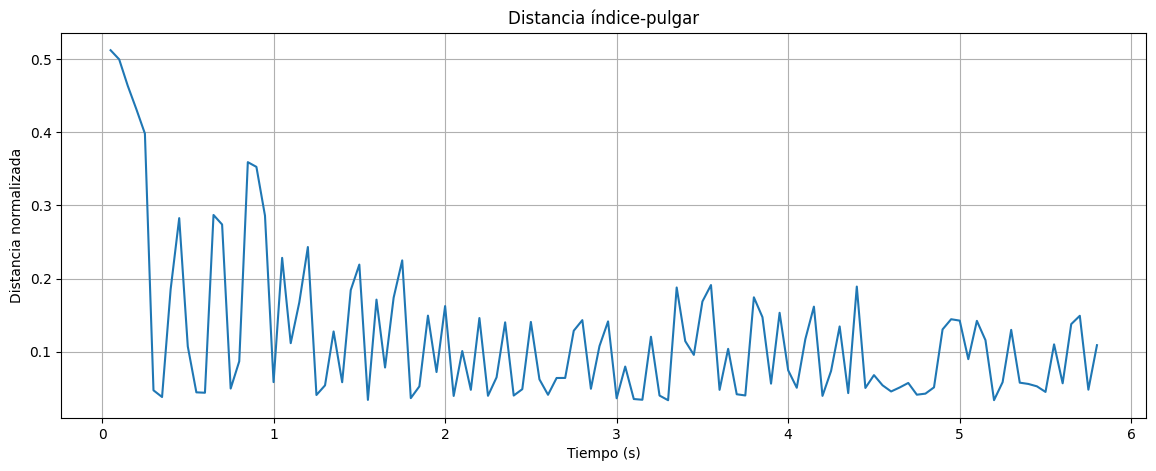

In [49]:
plt.figure(figsize=(14,5))
plt.plot(tiempos, distancias)
plt.title("Distancia índice-pulgar")
plt.xlabel("Tiempo (s)")
plt.ylabel("Distancia normalizada")
plt.grid()
plt.show()

In [70]:
# Detectar taps: mínimos en distancia
senal = np.array(distancias)

# invertimos para buscar mínimos
peaks, _ = find_peaks(-senal, distance=4, prominence=0.01)

print("Número de taps:", len(peaks))

Número de taps: 18


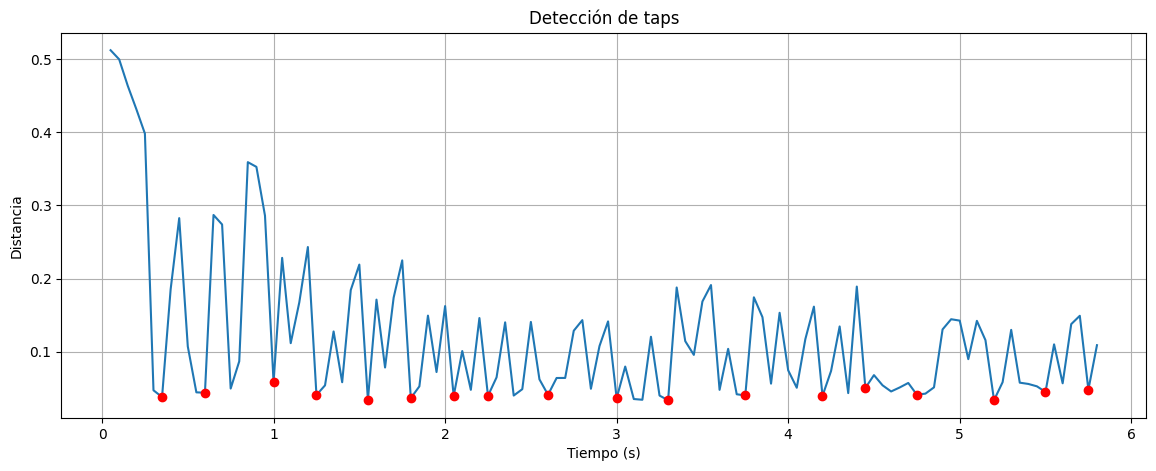

In [71]:
plt.figure(figsize=(14,5))
plt.plot(tiempos, senal)
plt.plot(np.array(tiempos)[peaks], senal[peaks], "ro")
plt.title("Detección de taps")
plt.xlabel("Tiempo (s)")
plt.ylabel("Distancia")
plt.grid()
plt.show()

### Features

In [74]:
import pandas as pd
import numpy as np

# Tiempo total
duracion = tiempos[-1] - tiempos[0]

# Velocidad
velocidad = len(peaks) / duracion

# Amplitud global
amplitud = np.nanmax(senal) - np.nanmin(senal)

# Variabilidad entre taps (titubeos)
tap_times = np.array(tiempos)[peaks]
intervalos = np.diff(tap_times)

variabilidad = np.std(intervalos) if len(intervalos) > 1 else 0

# Interrupciones (>1 segundo sin tap)
interrupciones = np.sum(intervalos > 1.0)

# Disminución amplitud inicio-final
n = len(senal)

amp_inicio = np.nanmean(senal[:n//3])
amp_final = np.nanmean(senal[-n//3:])

decremento = amp_inicio - amp_final

# Crear tabla
tabla = pd.DataFrame({
    "Feature": [
        "Número taps",
        "Velocidad (taps/s)",
        "Amplitud global",
        "Variabilidad ritmo",
        "Interrupciones",
        "Amplitud inicio",
        "Amplitud final",
        "Decremento amplitud"
    ],

    "Valor": [
        int(len(peaks)),
        round(velocidad,3),
        round(amplitud,4),
        round(variabilidad,4),
        int(interrupciones),
        round(amp_inicio,4),
        round(amp_final,4),
        round(decremento,4)
    ]
})

tabla

,Feature,Valor
0,Número taps,18.0000
1,Velocidad (taps/s),3.1030
2,Amplitud global,0.4787
3,Variabilidad ritmo,0.0803
4,Interrupciones,0.0000
5,Amplitud inicio,0.1886
6,Amplitud final,0.0863
7,Decremento amplitud,0.1023
